# Deep Learning for Microscopy: CycleGAN + Topological Loss

This notebook implements a CycleGAN framework enhanced with a **Wasserstein Topological Loss** to translate between conventional fluorescence and confocal microscopy images. 

## Key Features:
- **Modular Architecture:** Clean separation of configuration, TDA (Topological Data Analysis) logic, and training loops.
- **Topological Persistence:** Uses `Gudhi` to compute persistence diagrams for structural preservation.
- **Straight-Through Estimator:** Bridges the gap between non-differentiable TDA metrics and PyTorch backpropagation.
- **Project Alignment:** Configuration is synced with project documentation (`load_size=512`, `crop_size=256`).

### Deep Dive: Topological Loss via Persistent Homology

#### 1. Why use Topology?
Traditional losses (L1, SSIM) focus on pixel-level alignment. In microscopy, preserving **connectivity** (e.g., cell wall continuity) is often more critical. Topological loss penalizes the model for breaking structural connections or creating artificial holes.

#### 2. Persistent Homology
- **Filtration:** We treat the grayscale intensity as a landscape. As we "flood" it, pixels appear and merge.
- **Components ($H_0$) and Loops ($H_1$):** We track when these features appear (**Birth**) and merge (**Death**).
- **Persistence Diagram:** A 2D plot of these pairs. Persistent features (long-lived) represent real biological structures.

#### 3. Wasserstein Distance
We measure the "cost" of transforming the `fake` image's topology into the `real` image's topology using the Wasserstein metric on their diagrams.

#### 4. Differentiability via Straight-Through Estimator (STE)
Since TDA extraction is non-differentiable, we use an STE trick:
$$\mathcal{L} = \text{Surrogate} + (\text{TrueTopo} - \text{Surrogate}).\text{detach}()$$
- **Forward Pass:** The loss value equals the true topological distance.
- **Backward Pass:** Gradients are derived from a differentiable **Edge-Aware Surrogate** (Sobel + L1), which guides the generator toward better structural integrity.

In [ ]:
# Cell 1: Environment Setup
# gemini --resume b7e30bc6-9179-4be4-aab3-3fd023591e60
import os
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from types import SimpleNamespace
from collections import defaultdict

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import gudhi as gd
import gudhi.wasserstein

from data import create_dataset
from models.cycle_gan_model import CycleGANModel
from util import util

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("ggplot")

In [ ]:
# Cell 2: Global Configuration
@dataclass
class NotebookConfig:
    """Parameters aligned with PROJECT_REPORT.md and train.md."""
    dataroot: str = "./datasets/conventional2confocal"
    checkpoints_dir: str = "./checkpoints"
    results_dir: str = "./results/dlri_notebook"
    name: str = "conventional2confocal_cyclegan_topo"

    model: str = "cycle_gan"
    input_nc: int = 3
    output_nc: int = 3
    ngf: int = 64
    ndf: int = 64
    netG: str = "resnet_9blocks"
    netD: str = "basic"
    n_layers_D: int = 3
    norm: str = "instance"
    init_type: str = "normal"
    init_gain: float = 0.02
    no_dropout: bool = True

    dataset_mode: str = "unaligned"
    direction: str = "AtoB"
    batch_size: int = 1
    load_size: int = 512          # Standard for this project
    crop_size: int = 256
    preprocess: str = "scale_width_and_crop"
    no_flip: bool = False
    serial_batches: bool = False
    num_threads: int = 4
    max_dataset_size: float = float("inf")

    n_epochs: int = 1
    n_epochs_decay: int = 1
    epoch_count: int = 1
    lr: float = 2e-4
    beta1: float = 0.5
    gan_mode: str = "lsgan"
    pool_size: int = 50
    lr_policy: str = "linear"
    lr_decay_iters: int = 50
    lambda_A: float = 10.0
    lambda_B: float = 10.0
    lambda_identity: float = 0.5
    lambda_topo: float = 1.0

    topo_filtration: str = "sublevel"
    topo_weight_dim0: float = 0.6
    topo_weight_dim1: float = 0.4
    topo_threshold: float = 0.01
    topo_resize: int = 128
    topo_max_points: int = 256
    topo_surrogate_weight: float = 0.15

    save_epoch_freq: int = 100
    save_latest_freq: int = 5000
    save_by_iter: bool = False
    display_freq: int = 400
    update_html_freq: int = 1000
    print_freq: int = 100
    no_html: bool = True
    use_wandb: bool = False
    wandb_project_name: str = "CycleGAN-and-pix2pix"

    continue_train: bool = False
    epoch: str = "latest"
    load_iter: int = 0
    verbose: bool = False
    suffix: str = ""
    display_winsize: int = 256
    phase: str = "train"

    seed: int = 42
    preview_samples: int = 3
    test_epoch: str = "latest"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

NotebookConfig(dataroot='./datasets/conventional2confocal', checkpoints_dir='./checkpoints', results_dir='./results/dlri_notebook', name='conventional2confocal_cyclegan_topo', model='cycle_gan', input_nc=3, output_nc=3, ngf=64, ndf=64, netG='resnet_9blocks', netD='basic', n_layers_D=3, norm='instance', init_type='normal', init_gain=0.02, no_dropout=True, dataset_mode='unaligned', direction='AtoB', batch_size=1, load_size=512, crop_size=256, preprocess='scale_width_and_crop', no_flip=False, serial_batches=False, num_threads=4, max_dataset_size=inf, n_epochs=1, n_epochs_decay=1, epoch_count=1, lr=0.0002, beta1=0.5, gan_mode='lsgan', pool_size=50, lr_policy='linear', lr_decay_iters=50, lambda_A=10.0, lambda_B=10.0, lambda_identity=0.5, lambda_topo=1.0, topo_filtration='sublevel', topo_weight_dim0=0.6, topo_weight_dim1=0.4, topo_threshold=0.01, topo_resize=128, topo_max_points=256, topo_surrogate_weight=0.15, save_epoch_freq=100, save_latest_freq=5000, save_by_iter=False, display_freq=400,

In [ ]:

def build_options(cfg: NotebookConfig, *, is_train: bool, phase: str) -> SimpleNamespace:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    return SimpleNamespace(
        isTrain=is_train,
        dataroot=cfg.dataroot,
        name=cfg.name,
        model=cfg.model,
        checkpoints_dir=cfg.checkpoints_dir,
        input_nc=cfg.input_nc,
        output_nc=cfg.output_nc,
        ngf=cfg.ngf,
        ndf=cfg.ndf,
        netG=cfg.netG,
        netD=cfg.netD,
        n_layers_D=cfg.n_layers_D,
        norm=cfg.norm,
        init_type=cfg.init_type,
        init_gain=cfg.init_gain,
        no_dropout=cfg.no_dropout,
        dataset_mode=cfg.dataset_mode,
        direction=cfg.direction,
        batch_size=cfg.batch_size,
        load_size=cfg.load_size,
        crop_size=cfg.crop_size,
        preprocess=cfg.preprocess,
        no_flip=cfg.no_flip,
        serial_batches=(cfg.serial_batches if is_train else True),
        num_threads=cfg.num_threads,
        max_dataset_size=cfg.max_dataset_size,
        display_winsize=cfg.display_winsize,
        epoch=cfg.epoch if is_train else cfg.test_epoch,
        load_iter=cfg.load_iter,
        verbose=cfg.verbose,
        suffix=cfg.suffix,
        use_wandb=cfg.use_wandb,
        wandb_project_name=cfg.wandb_project_name,
        phase=phase,
        display_freq=cfg.display_freq,
        update_html_freq=cfg.update_html_freq,
        print_freq=cfg.print_freq,
        no_html=cfg.no_html,
        save_latest_freq=cfg.save_latest_freq,
        save_epoch_freq=cfg.save_epoch_freq,
        save_by_iter=cfg.save_by_iter,
        continue_train=cfg.continue_train if is_train else False,
        epoch_count=cfg.epoch_count,
        n_epochs=cfg.n_epochs,
        n_epochs_decay=cfg.n_epochs_decay,
        beta1=cfg.beta1,
        lr=cfg.lr,
        gan_mode=cfg.gan_mode,
        pool_size=cfg.pool_size,
        lr_policy=cfg.lr_policy,
        lr_decay_iters=cfg.lr_decay_iters,
        lambda_A=cfg.lambda_A,
        lambda_B=cfg.lambda_B,
        lambda_identity=cfg.lambda_identity,
        lambda_topo=cfg.lambda_topo,
        topo_filtration=cfg.topo_filtration,
        topo_weight_dim0=cfg.topo_weight_dim0,
        topo_weight_dim1=cfg.topo_weight_dim1,
        topo_threshold=cfg.topo_threshold,
        topo_resize=cfg.topo_resize,
        topo_max_points=cfg.topo_max_points,
        topo_surrogate_weight=cfg.topo_surrogate_weight,
        device=device,
        gpu_ids=[0] if torch.cuda.is_available() else [],
    )

In [ ]:
CONFIG = NotebookConfig()
set_seed(CONFIG.seed)
Path(CONFIG.results_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.checkpoints_dir).mkdir(parents=True, exist_ok=True)
print(CONFIG)
print(f"Notebook device: {build_options(CONFIG, is_train=True, phase='train').device}")

In [ ]:
# Cell 3: Differentiable Topological Loss Implementation
def normalized_to_grayscale(batch: torch.Tensor) -> torch.Tensor:
    """Converts CycleGAN normalized tensor [-1, 1] to Grayscale [0, 1]."""
    batch_01 = (batch.clamp(-1.0, 1.0) + 1.0) / 2.0
    if batch_01.shape[1] == 1:
        return batch_01
    weights = torch.tensor([0.2989, 0.5870, 0.1140], device=batch.device, dtype=batch.dtype).view(1, 3, 1, 1)
    return (batch_01[:, :3] * weights).sum(dim=1, keepdim=True)


def _filter_topology_points(diagram: np.ndarray, threshold: float, max_points: int) -> np.ndarray:
    """Cleans persistence diagrams by removing noise and limiting point count."""
    if diagram.size == 0:
        return np.zeros((0, 2), dtype=np.float64)
    mask = np.isfinite(diagram[:, 1]) & ((diagram[:, 1] - diagram[:, 0]) > threshold)
    filtered = diagram[mask]
    if filtered.size == 0:
        return np.zeros((0, 2), dtype=np.float64)
    persistence = filtered[:, 1] - filtered[:, 0]
    keep = np.argsort(persistence)[-max_points:]
    return filtered[keep].astype(np.float64, copy=False)


def _persistence_diagrams(image_2d: np.ndarray, filtration: str, threshold: float, max_points: int):
    """Computes persistence diagrams for H0 and H1 using Gudhi Cubical Complex."""
    if filtration == "sublevel":
        filt_arr = image_2d
    elif filtration == "superlevel":
        filt_arr = 1.0 - image_2d
    else:
        raise ValueError("Supported filtrations: 'sublevel', 'superlevel'")

    complex_ = gd.CubicalComplex(dimensions=filt_arr.shape, top_dimensional_cells=filt_arr.flatten())
    complex_.persistence()
    dim0 = _filter_topology_points(complex_.persistence_intervals_in_dimension(0), threshold, max_points)
    dim1 = _filter_topology_points(complex_.persistence_intervals_in_dimension(1), threshold, max_points)
    return dim0, dim1


def _safe_wasserstein(dgm_a: np.ndarray, dgm_b: np.ndarray) -> float:
    """Calculates Wasserstein distance between two diagrams."""
    if dgm_a.size == 0 and dgm_b.size == 0:
        return 0.0
    dgm_a = dgm_a.reshape(-1, 2)
    dgm_b = dgm_b.reshape(-1, 2)
    return float(gd.wasserstein.wasserstein_distance(dgm_a, dgm_b, order=1.0, keep_essential_parts=False))


def _sobel_edges(gray_batch: torch.Tensor) -> torch.Tensor:
    """Differentiable edge detection for structural surrogate loss."""
    kernel_x = torch.tensor([[1.0, 0.0, -1.0], [2.0, 0.0, -2.0], [1.0, 0.0, -1.0]], device=gray_batch.device, dtype=gray_batch.dtype).view(1, 1, 3, 3)
    kernel_y = torch.tensor([[1.0, 2.0, 1.0], [0.0, 0.0, 0.0], [-1.0, -2.0, -1.0]], device=gray_batch.device, dtype=gray_batch.dtype).view(1, 1, 3, 3)
    grad_x = F.conv2d(gray_batch, kernel_x, padding=1)
    grad_y = F.conv2d(gray_batch, kernel_y, padding=1)
    return torch.sqrt(grad_x.pow(2) + grad_y.pow(2) + 1e-6)

In [ ]:
class WassersteinTopologicalLoss(nn.Module):
    """
    Gudhi-based Topological Loss with Straight-Through Estimator.
    """
    def __init__(self, cfg: NotebookConfig):
        super().__init__()
        self.cfg = cfg

    def topology_value(self, fake: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        """Extract exact TDA distance (non-differentiable value)."""
        fake_gray = normalized_to_grayscale(fake)
        ref_gray = normalized_to_grayscale(reference)
        fake_small = F.interpolate(fake_gray, size=(self.cfg.topo_resize, self.cfg.topo_resize), mode="bilinear", align_corners=False)
        ref_small = F.interpolate(ref_gray, size=(self.cfg.topo_resize, self.cfg.topo_resize), mode="bilinear", align_corners=False)

        topo_values = []
        for fake_img, ref_img in zip(fake_small, ref_small):
            fake_np = fake_img.squeeze(0).detach().cpu().numpy().astype(np.float64)
            ref_np = ref_img.squeeze(0).detach().cpu().numpy().astype(np.float64)
            fake_d0, fake_d1 = _persistence_diagrams(fake_np, self.cfg.topo_filtration, self.cfg.topo_threshold, self.cfg.topo_max_points)
            ref_d0, ref_d1 = _persistence_diagrams(ref_np, self.cfg.topo_filtration, self.cfg.topo_threshold, self.cfg.topo_max_points)
            score = self.cfg.topo_weight_dim0 * _safe_wasserstein(fake_d0, ref_d0) + self.cfg.topo_weight_dim1 * _safe_wasserstein(fake_d1, ref_d1)
            topo_values.append(score)

        return torch.tensor(float(np.mean(topo_values)), device=fake.device, dtype=fake.dtype)

    def surrogate(self, fake: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        """Compute differentiable edge-aware surrogate."""
        fake_gray = normalized_to_grayscale(fake)
        ref_gray = normalized_to_grayscale(reference)
        fake_small = F.interpolate(fake_gray, size=(self.cfg.topo_resize, self.cfg.topo_resize), mode="bilinear", align_corners=False)
        ref_small = F.interpolate(ref_gray, size=(self.cfg.topo_resize, self.cfg.topo_resize), mode="bilinear", align_corners=False)
        edge_term = F.l1_loss(_sobel_edges(fake_small), _sobel_edges(ref_small))
        intensity_term = F.l1_loss(fake_small, ref_small)
        return edge_term + self.cfg.topo_surrogate_weight * intensity_term

    def forward(self, fake: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        topo_value = self.topology_value(fake, reference)
        surrogate = self.surrogate(fake, reference)
        # STE Trick: Value from TDA, Gradients from Surrogate
        return surrogate + (topo_value - surrogate.detach())

In [ ]:
class TopoCycleGANModel(CycleGANModel):
    """Extended CycleGAN that incorporates topological preservation."""
    def __init__(self, opt):
        super().__init__(opt)
        if self.isTrain:
            self.loss_names += ["topo_A", "topo_B", "topo"]
            self.criterionTopo = WassersteinTopologicalLoss(opt)

    def train(self):
        """Set all networks to training mode."""
        for name in self.model_names:
            if isinstance(name, str):
                net = getattr(self, "net" + name)
                net.train()

    def backward_G(self):
        """Modified backward pass including the topological loss component."""
        lambda_idt = self.opt.lambda_identity
        lambda_A = self.opt.lambda_A
        lambda_B = self.opt.lambda_B

        # Identity Loss
        if lambda_idt > 0:
            self.idt_A = self.netG_A(self.real_B)
            self.loss_idt_A = self.criterionIdt(self.idt_A, self.real_B) * lambda_B * lambda_idt
            self.idt_B = self.netG_B(self.real_A)
            self.loss_idt_B = self.criterionIdt(self.idt_B, self.real_A) * lambda_A * lambda_idt
        else:
            self.loss_idt_A = self.loss_idt_B = 0

        # GAN Loss
        self.loss_G_A = self.criterionGAN(self.netD_A(self.fake_B), True)
        self.loss_G_B = self.criterionGAN(self.netD_B(self.fake_A), True)

        # Cycle Consistency Loss
        self.loss_cycle_A = self.criterionCycle(self.rec_A, self.real_A) * lambda_A
        self.loss_cycle_B = self.criterionCycle(self.rec_B, self.real_B) * lambda_B

        # Topological Loss
        if self.opt.lambda_topo > 0:
            self.loss_topo_A = self.criterionTopo(self.fake_B, self.real_A)
            self.loss_topo_B = self.criterionTopo(self.fake_A, self.real_B)
            self.loss_topo = 0.5 * (self.loss_topo_A + self.loss_topo_B) * self.opt.lambda_topo
        else:
            self.loss_topo_A = self.loss_topo_B = self.loss_topo = torch.tensor(0.0, device=self.device)

        # Total Generator Loss
        self.loss_G = (
            self.loss_G_A + self.loss_G_B +
            self.loss_cycle_A + self.loss_cycle_B +
            self.loss_idt_A + self.loss_idt_B +
            self.loss_topo
        )
        self.loss_G.backward()

In [26]:
# Cell 4: Model and Dataset Factory
def create_topo_model(cfg: NotebookConfig, *, is_train: bool = True):
    opt = build_options(cfg, is_train=is_train, phase=("train" if is_train else "test"))
    model = TopoCycleGANModel(opt)
    model.setup(opt)
    return model, opt

def create_topo_dataset(cfg: NotebookConfig, *, phase: str, is_train: bool):
    if not (Path(cfg.dataroot) / f"{phase}A").exists():
        return None, None
    opt = build_options(cfg, is_train=is_train, phase=phase)
    dataset = create_dataset(opt)
    return dataset, opt

def check_models_exist(cfg: NotebookConfig):
    """Check if core network weights exist in the checkpoints directory."""
    save_dir = Path(cfg.checkpoints_dir) / cfg.name
    for name in ["G_A", "G_B", "D_A", "D_B"]:
        if not (save_dir / f"latest_net_{name}.pth").exists():
            return False
    return True

model, train_opt = create_topo_model(CONFIG, is_train=True)
train_dataset, _ = create_topo_dataset(CONFIG, phase="train", is_train=True)
test_dataset, _ = create_topo_dataset(CONFIG, phase="test", is_train=False)

print(f"Model initialized on {train_opt.device}")
print(f"Dataset: {len(train_dataset) if train_dataset else 0} training batches.")

Initialized with device cuda:0
initialize network with normal
Initialized with device cuda:0
initialize network with normal
Initialized with device cuda:0
initialize network with normal
Initialized with device cuda:0
initialize network with normal
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 11.378 M
[Network G_B] Total number of parameters : 11.378 M
[Network D_A] Total number of parameters : 2.765 M
[Network D_B] Total number of parameters : 2.765 M
-----------------------------------------------
dataset [UnalignedDataset] was created
dataset [UnalignedDataset] was created
Model initialized on cuda:0
Dataset: 15 training batches.


In [27]:
# Cell 5: Training Infrastructure
history = defaultdict(list)

def train_model(model, dataset, opt, cfg: NotebookConfig):
    if dataset is None: raise FileNotFoundError("Dataset folders missing.")

    total_iters = 0
    start_time = time.time()

    for epoch in range(opt.epoch_count, opt.n_epochs + opt.n_epochs_decay + 1):
        epoch_start = time.time()
        epoch_losses = defaultdict(list)
        
        for step, batch in enumerate(dataset, start=1):
            total_iters += opt.batch_size
            model.set_input(batch)
            model.optimize_parameters()
            
            current_losses = model.get_current_losses()
            for name, value in current_losses.items():
                epoch_losses[name].append(float(value))

            if step % cfg.print_freq == 0:
                print(f"E{epoch} S{step}: G_Total={current_losses.get('G', 0):.4f} Topo={current_losses.get('topo', 0):.4f}")

        # Epoch Stats
        history["epoch"].append(epoch)
        for name, values in epoch_losses.items():
            history[name].append(float(np.mean(values)))

        model.update_learning_rate()
        if epoch % cfg.save_epoch_freq == 0:
            model.save_networks(epoch)
            model.save_networks("latest")

        print(f"Finished Epoch {epoch} in {time.time() - epoch_start:.1f}s")

    print(f"Total training time: {(time.time() - start_time) / 60.0:.2f} min")
    return history

In [28]:
# Cell 6: Run Training (Conditional)
if not check_models_exist(CONFIG):
    print("No pre-trained models found. Starting training...")
    history = train_model(model, train_dataset, train_opt, CONFIG)
else:
    print("Pre-trained models found in checkpoints directory. Skipping training.")

No pre-trained models found. Starting training...
learning rate 0.0002000 -> 0.0001000
Finished Epoch 1 in 11.9s
learning rate 0.0001000 -> 0.0000000
Finished Epoch 2 in 11.1s
Total training time: 0.38 min


In [29]:
# Cell 7: Inference and Evaluation
def run_evaluation(model, dataset, cfg: NotebookConfig, max_items=None):
    if dataset is None: return []
    results = []
    model.eval()
    output_dir = Path(cfg.results_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for idx, batch in enumerate(dataset):
        if max_items and idx >= max_items: break
        model.set_input(batch)
        model.test()
        
        topo_score = model.criterionTopo.topology_value(model.fake_B, model.real_A).item() if hasattr(model, 'criterionTopo') else 0
        
        res = {
            "real_A": util.tensor2im(model.real_A), "fake_B": util.tensor2im(model.fake_B),
            "real_B": util.tensor2im(model.real_B), "fake_A": util.tensor2im(model.fake_A),
            "topo_A": topo_score
        }
        results.append(res)
        util.save_image(res["fake_B"], output_dir / f"eval_{idx}_fake_B.png")

    model.train()
    return results

if test_dataset:
    eval_results = run_evaluation(model, test_dataset, CONFIG, max_items=CONFIG.preview_samples)
    print(f"Generated {len(eval_results)} preview samples.")

Generated 1 preview samples.


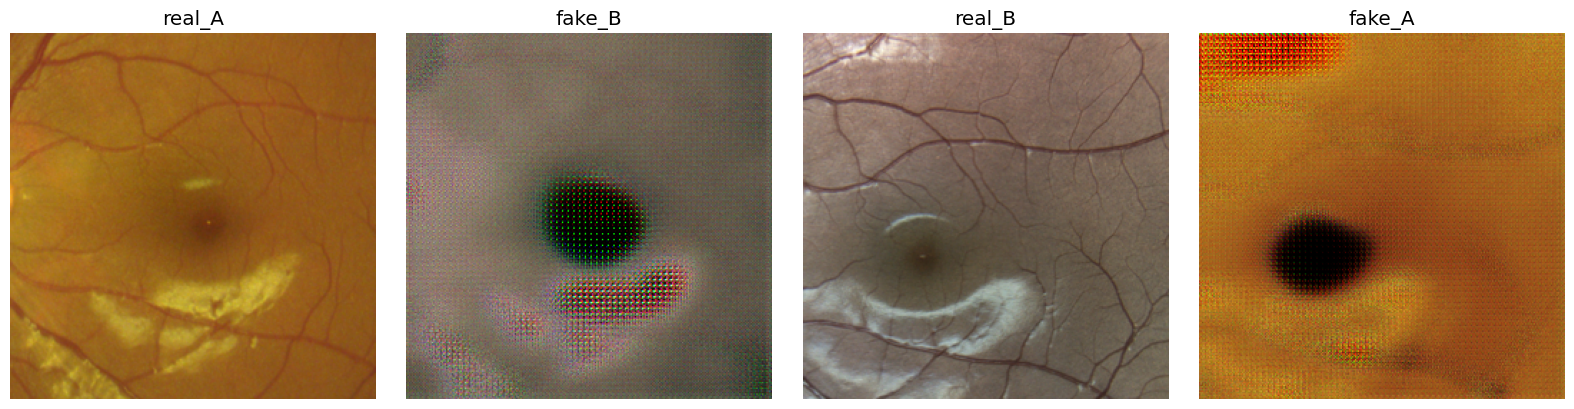

In [30]:
# Cell 8: Visual Results
if eval_results:
    fig, axes = plt.subplots(len(eval_results), 4, figsize=(16, 4 * len(eval_results)))
    cols = ["real_A", "fake_B", "real_B", "fake_A"]
    
    for i, res in enumerate(eval_results):
        curr_axes = axes[i] if len(eval_results) > 1 else axes
        for j, col in enumerate(cols):
            curr_axes[j].imshow(res[col])
            curr_axes[j].set_title(col)
            curr_axes[j].axis("off")
        curr_axes[0].set_ylabel(f"Topo: {res['topo_A']:.3f}", rotation=0, labelpad=40, size='large')
    
    plt.tight_layout()
    plt.show()